In [1]:
import os
import sys
import argparse

import seaborn as sns
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data import *
from utils import *
from scipy import stats
from datetime import datetime
from matplotlib.patches import Rectangle
from scipy.stats import kruskal, f_oneway

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

from BA import oh_binary_accuracy

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=5_000, help='Total # of samples') # 2_000 -> 5_000
parser.add_argument('--mb_size', type=int, default=32, help='Mini-batch size. See utils.py') # 64 -> 32; maybe 48?
parser.add_argument('--h_dim', type=int, default=48, help='Dim of latent vector') # 48 -> 64; maybe 64
parser.add_argument('--capacity', type=int, default=48, help='Capacity of network. See utils.py')

parser.add_argument('--x_fdim', type=int, default=256, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=256, help='Input y_fdim. See utils.py')
parser.add_argument('--z_fdim', type=int, default=64, help='Input z_fdim. See utils.py')

parser.add_argument('--c_accu', type=float, default=50, help='Input weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

parser.add_argument('--lr', type=float, default=7e-05, help='Input learning rate for optimizer') # 1e-4 -> 7e-5 -> 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 100 -> 300 -> 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

In [3]:
_, xtest, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

info 0 5000 1


/Users/arthurclarysse/Desktop/🎓/03 Masterproef CS/VUB-MT-Development/Models/GenRKM-MMCelebHQ-V3/data.py:31: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  label = torch.tensor(label, dtype=torch.double).T


info 5001 10001 1


In [4]:
def kPCA(X, Y, Z, nviews=3, eps=1e-6):
    if nviews == 3:
        a = (X @ X.T + Y @ Y.T + Z @ Z.T) / nviews
    elif nviews == 2:
        a = (X @ X.T + Y @ Y.T) / nviews
    else:
        a = (X @ X.T) / nviews

    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)

    return h, s

In [5]:
model_1V = torch.load('./out/Final-1V.tar', weights_only=False)
model_2V_IS = torch.load('./out/Final-2V-IS.tar', weights_only=False)
model_2V_IL = torch.load('./out/Final-2V-IL.tar', weights_only=False)
model_3V = torch.load('./out/Final.tar', weights_only=False)

In [6]:
# Single View Networks
net_im_en_1V = model_1V['net_im_en']
net_im_de_1V = model_1V['net_im_de']

# Two View Networks - Image + Sketch
net_im_en_2V_IS = model_2V_IS['net_im_en']
net_sk_en_2V_IS = model_2V_IS['net_sk_en']

net_im_de_2V_IS = model_2V_IS['net_im_de']
net_sk_de_2V_IS = model_2V_IS['net_sk_de']

# Two View Networks - Image + Label
net_im_en_2V_IL = model_2V_IL['net_im_en']
net_la_en_2V_IL = model_2V_IL['net_la_en']

net_im_de_2V_IL = model_2V_IL['net_im_de']
net_la_de_2V_IL = model_2V_IL['net_la_de']

# Three View Networks - Image + Sketch + Label
net_im_en_3V = model_3V['net_im_en']
net_sk_en_3V = model_3V['net_sk_en']
net_la_en_3V = model_3V['net_la_en']

net_im_de_3V = model_3V['net_im_de']
net_sk_de_3V = model_3V['net_sk_de']
net_la_de_3V = model_3V['net_la_de']

In [7]:
net_im_en_1V.eval()
net_im_en_2V_IS.eval()
net_sk_en_2V_IS.eval()
net_im_en_2V_IL.eval()
net_la_en_2V_IL.eval()
net_im_en_3V.eval()
net_sk_en_3V.eval()
net_la_en_3V.eval()

net_im_de_1V.eval()
net_im_de_2V_IS.eval()
net_sk_de_2V_IS.eval()
net_im_de_2V_IL.eval()
net_la_de_2V_IL.eval()
net_im_de_3V.eval()
net_sk_de_3V.eval()
net_la_de_3V.eval()

NetLaDe(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Linear(in_features=128, out_features=256, bias=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (drop2): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=256, out_features=40, bias=True)
)

In [8]:
all_data_im, all_data_sk, all_data_la = [], [], []

im_en_1V = []
im_en_2V_IS, sk_en_2V_IS = [], []
im_en_2V_IL, la_en_2V_IL = [], []
im_en_3V, sk_en_3V, la_en_3V = [], [], []

im_de_1V = []
im_de_2V_IS, sk_de_2V_IS = [], []
im_de_2V_IL, la_de_2V_IL = [], []
im_de_3V, sk_de_3V, la_de_3V = [], [], []

im_loss_1V = []
im_loss_2V_IS, sk_loss_2V_IS, loss_2V_IS = [], [], []
im_loss_2V_IL, la_loss_2V_IL, loss_2V_IL = [], [], []
im_loss_3V, sk_loss_3V, la_loss_3V, loss_3V = [], [], [], []

In [9]:
recon_loss1 = torch.nn.MSELoss()
recon_loss2 = torch.nn.MSELoss()
recon_loss3 = torch.nn.BCEWithLogitsLoss()

In [10]:
with torch.no_grad():
    for i, (im, sk, la) in enumerate(xtest):
        if i > 999:
            break

        im = im.to(opt.device)
        sk = sk.to(opt.device)
        la = la.to(opt.device)

        all_data_im.append(im.cpu())
        all_data_sk.append(sk.cpu())
        all_data_la.append(la.cpu())

        # Single View
        im_en_1V.append(net_im_en_1V(im).cpu())

        # Two View - Image + Sketch
        im_en_2V_IS.append(net_im_en_2V_IS(im).cpu())
        sk_en_2V_IS.append(net_sk_en_2V_IS(sk).cpu())

        # Two View - Image + Label
        im_en_2V_IL.append(net_im_en_2V_IL(im).cpu())
        la_en_2V_IL.append(net_la_en_2V_IL(la).cpu())

        # Three View - Image + Sketch + Label
        im_en_3V.append(net_im_en_3V(im).cpu())
        sk_en_3V.append(net_sk_en_3V(sk).cpu())
        la_en_3V.append(net_la_en_3V(la).cpu())

In [11]:
all_data_im = torch.cat(all_data_im, dim=0)
all_data_sk = torch.cat(all_data_sk, dim=0)
all_data_la = torch.cat(all_data_la, dim=0)

im_en_1V = torch.cat(im_en_1V, dim=0)
im_en_2V_IS = torch.cat(im_en_2V_IS, dim=0)
sk_en_2V_IS = torch.cat(sk_en_2V_IS, dim=0)
im_en_2V_IL = torch.cat(im_en_2V_IL, dim=0)
la_en_2V_IL = torch.cat(la_en_2V_IL, dim=0)
im_en_3V = torch.cat(im_en_3V, dim=0)
sk_en_3V = torch.cat(sk_en_3V, dim=0)
la_en_3V = torch.cat(la_en_3V, dim=0)

In [12]:
with torch.no_grad():
    for i in range(10):
        start, stop = i * 100, (i + 1) * 100

        # Get latent representations (current batch of 100 samples)
        h_1V, _ = kPCA(im_en_1V[start:stop], None, None, nviews=1)
        h_2V_IS, _ = kPCA(im_en_2V_IS[start:stop], sk_en_2V_IS[start:stop], None, nviews=2)
        h_2V_IL, _ = kPCA(im_en_2V_IL[start:stop], la_en_2V_IL[start:stop], None, nviews=2)
        h_3V, _ = kPCA(im_en_3V[start:stop], sk_en_3V[start:stop], la_en_3V[start:stop], nviews=3)

        # Calculate U // All views
        U_1V = im_en_1V[start:stop].T @ h_1V
        U_2V_IS = im_en_2V_IS[start:stop].T @ h_2V_IS
        U_2V_IL = im_en_2V_IL[start:stop].T @ h_2V_IL
        U_3V = im_en_3V[start:stop].T @ h_3V

        # Calculate V // 2V-IS and 3V only
        V_2V_IS = sk_en_2V_IS[start:stop].T @ h_2V_IS
        V_3V = sk_en_3V[start:stop].T @ h_3V

        # Calculate W // 2V-IL and 3V only
        W_2V_IL = la_en_2V_IL[start:stop].T @ h_2V_IL
        W_3V = la_en_3V[start:stop].T @ h_3V

        # Reconstruct images, sketches, labels from latent representations
        im_1V_tilde = net_im_de_1V(h_1V @ U_1V.T)
        im_2V_IS_tilde = net_im_de_2V_IS(h_2V_IS @ U_2V_IS.T)
        im_2V_IL_tilde = net_im_de_2V_IL(h_2V_IL @ U_2V_IL.T)
        im_3V_tilde = net_im_de_3V(h_3V @ U_3V.T)

        sk_2V_IS_tilde = net_sk_de_2V_IS(h_2V_IS @ V_2V_IS.T)
        sk_3V_tilde = net_sk_de_3V(h_3V @ V_3V.T)

        la_2V_IL_tilde = net_la_de_2V_IL(h_2V_IL @ W_2V_IL.T)
        la_3V_tilde = net_la_de_3V(h_3V @ W_3V.T)

        # Calculate losses
        im_true = all_data_im[start:stop]
        sk_true = all_data_sk[start:stop]
        la_true = all_data_la[start:stop]

        im_loss_1V.append(recon_loss1(im_1V_tilde.view(im_1V_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))
        im_loss_2V_IS.append(recon_loss1(im_2V_IS_tilde.view(im_2V_IS_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))
        im_loss_2V_IL.append(recon_loss1(im_2V_IL_tilde.view(im_2V_IL_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))
        im_loss_3V.append(recon_loss1(im_3V_tilde.view(im_3V_tilde.size(0), -1), im_true.view(im_true.size(0), -1)))

        sk_loss_2V_IS.append(recon_loss2(sk_2V_IS_tilde.view(sk_2V_IS_tilde.size(0), -1), sk_true.view(sk_true.size(0), -1)))
        sk_loss_3V.append(recon_loss2(sk_3V_tilde.view(sk_3V_tilde.size(0), -1), sk_true.view(sk_true.size(0), -1)))

        la_loss_2V_IL.append(recon_loss3(la_2V_IL_tilde.view(la_2V_IL_tilde.size(0), -1), la_true.view(la_true.size(0), -1)))
        la_loss_3V.append(recon_loss3(la_3V_tilde.view(la_3V_tilde.size(0), -1), la_true.view(la_true.size(0), -1)))

        # Store some samples for visualization
        if i == 0:
            im_de_1V.append(im_1V_tilde.cpu()[:10])
            im_de_2V_IS.append(im_2V_IS_tilde.cpu()[:10])
            im_de_2V_IL.append(im_2V_IL_tilde.cpu()[:10])
            im_de_3V.append(im_3V_tilde.cpu()[:10])
            sk_de_2V_IS.append(sk_2V_IS_tilde.cpu()[:10])
            sk_de_3V.append(sk_3V_tilde.cpu()[:10])
            la_de_2V_IL.append(la_2V_IL_tilde.cpu()[:10])
            la_de_3V.append(la_3V_tilde.cpu()[:10])

        print(f'Batch {i + 1}/10 processed.')

Batch 1/10 processed.
Batch 2/10 processed.
Batch 3/10 processed.
Batch 4/10 processed.
Batch 5/10 processed.
Batch 6/10 processed.
Batch 7/10 processed.
Batch 8/10 processed.
Batch 9/10 processed.
Batch 10/10 processed.


## Plotting

In [13]:
# Plot the losses, 4 categories on the x-axis: 1V, 2V-IS, 2V-IL, 3V; and 3 bars for each category: image, sketch, label if applicable
categories = ['1V', '2V-IS', '2V-IL', '3V']

im_losses = [
    torch.stack(im_loss_1V).mean(),
    torch.stack(im_loss_2V_IS).mean(),
    torch.stack(im_loss_2V_IL).mean(),
    torch.stack(im_loss_3V).mean()
]

sk_losses = [
    None,
    torch.stack(sk_loss_2V_IS).mean(),
    None,
    torch.stack(sk_loss_3V).mean()
]

la_losses = [
    None,
    None,
    torch.stack(la_loss_2V_IL).mean(),
    torch.stack(la_loss_3V).mean()
]

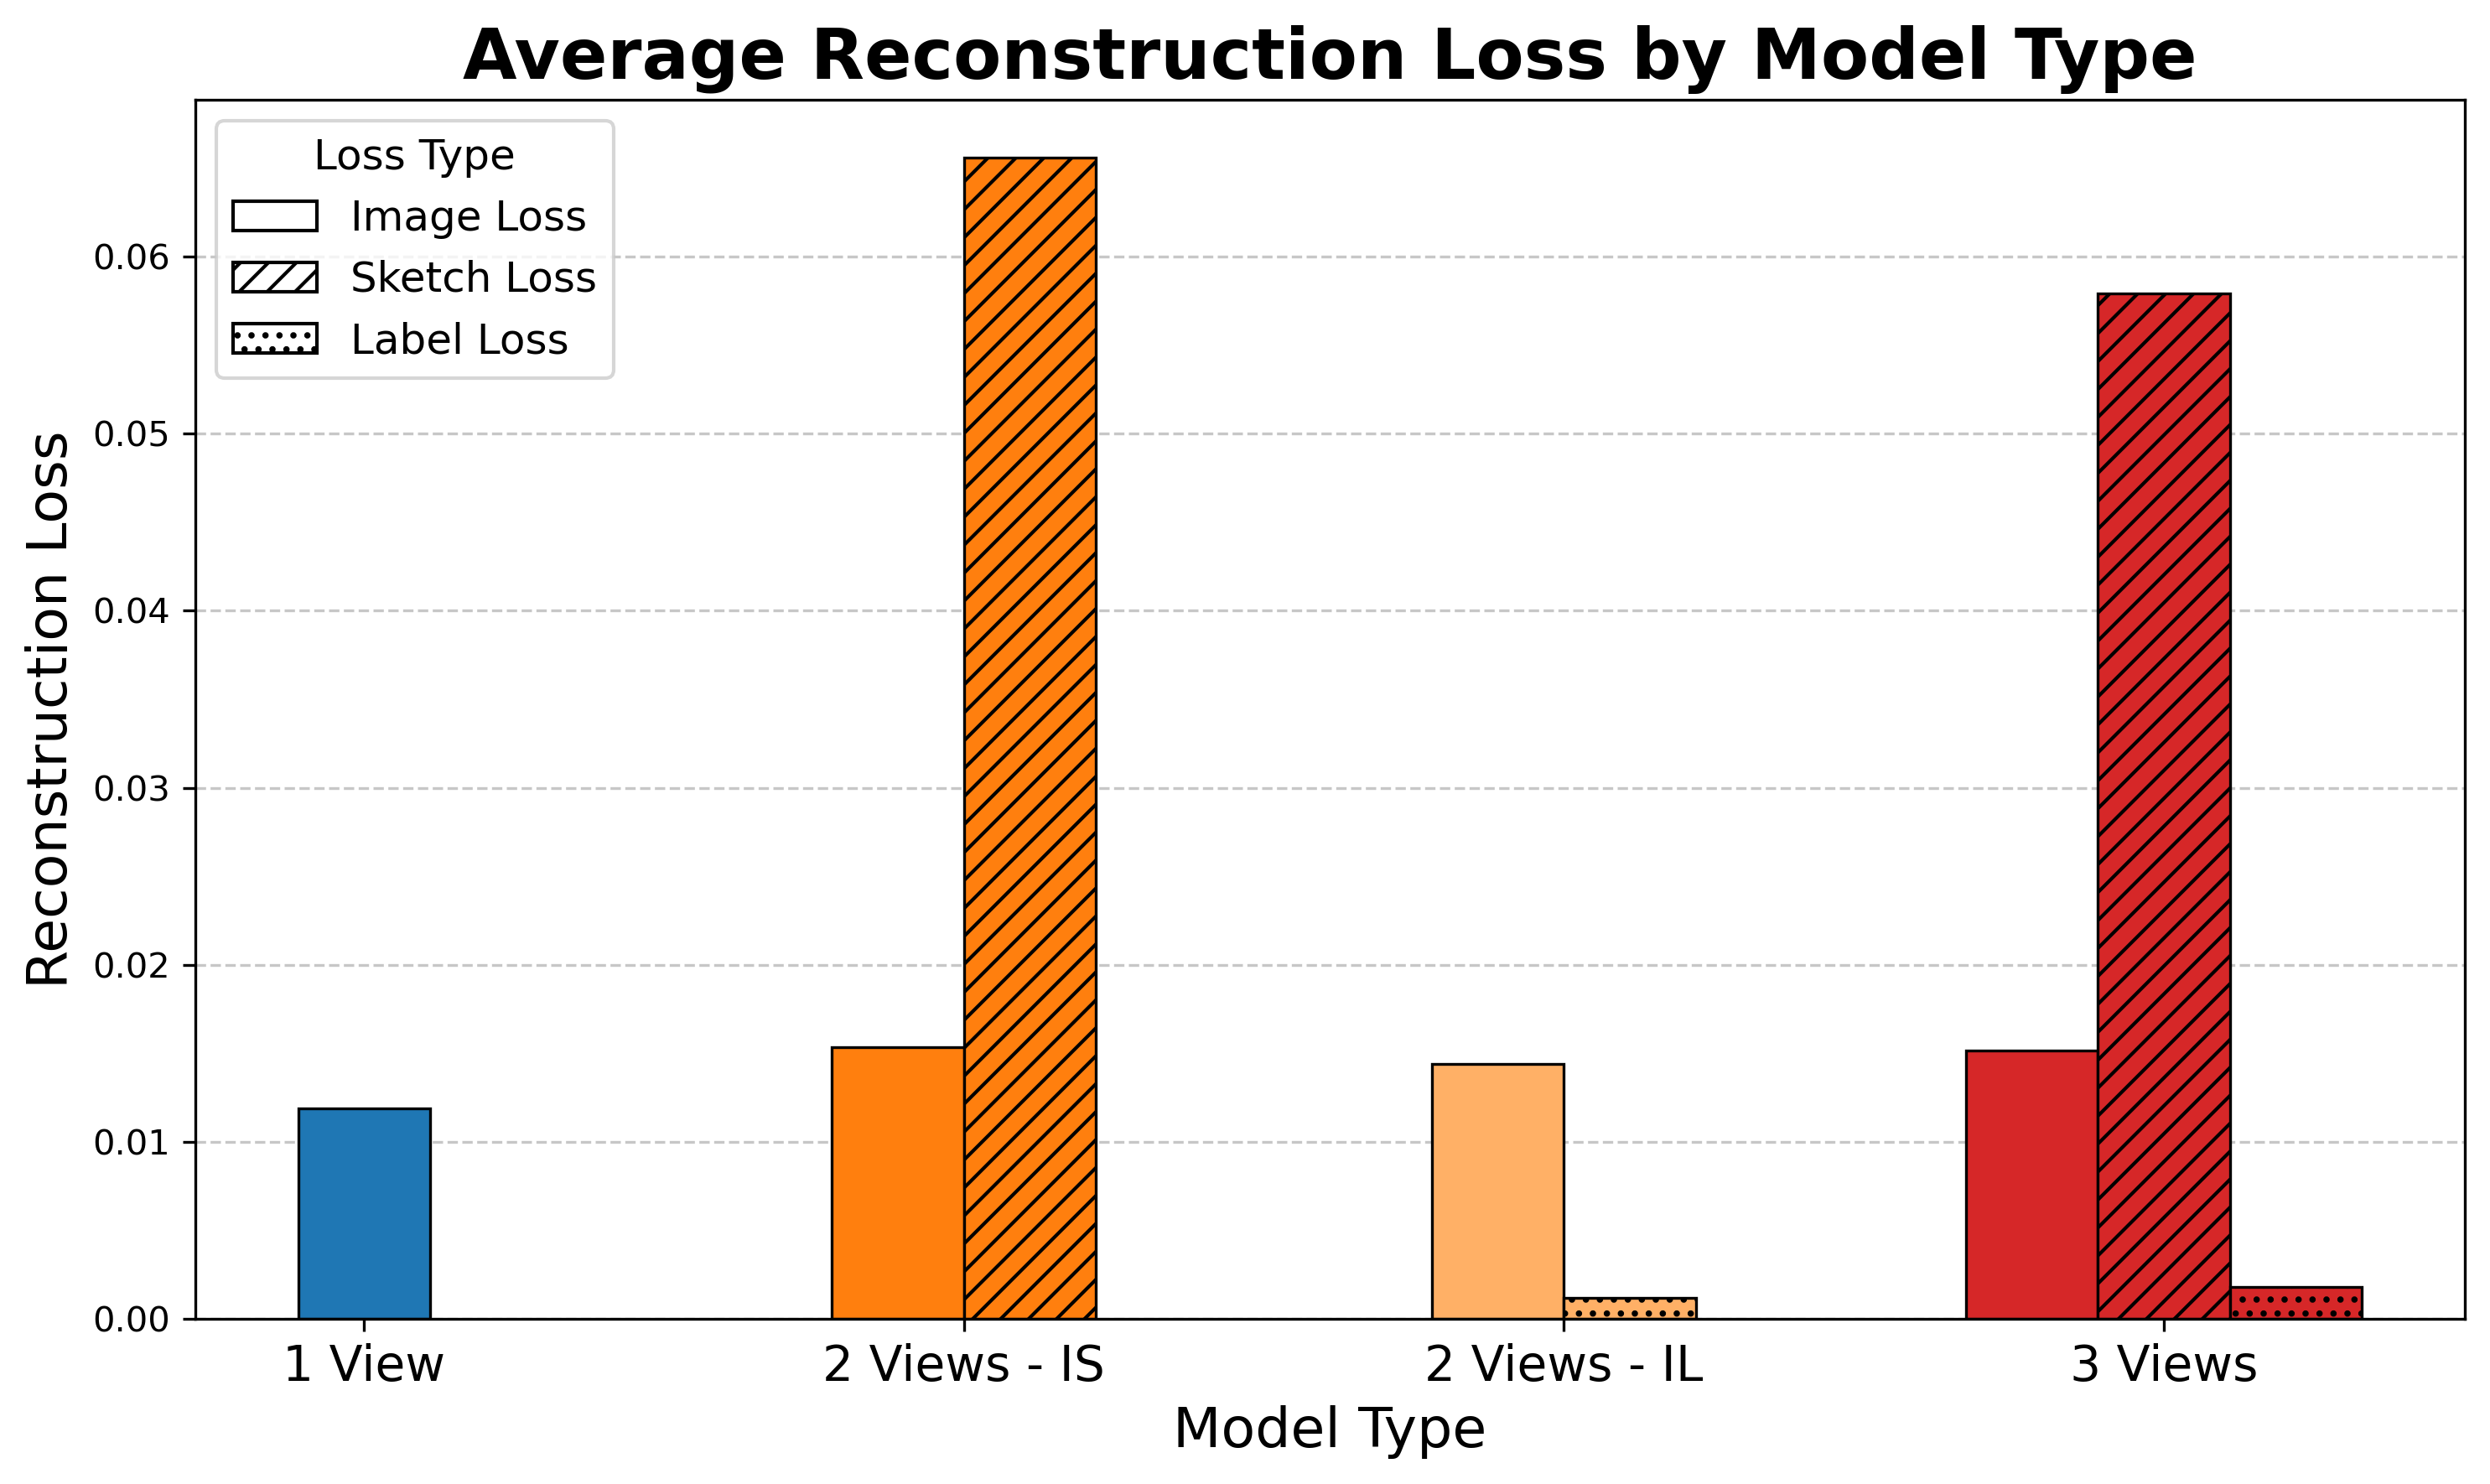

In [14]:
categories = ['1 View', '2 Views - IS', '2 Views - IL', '3 Views']
x = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bar_width = 0.22

model_color_map = {
    '1 View': 'tab:blue',
    '2 Views - IS': 'tab:orange',
    '2 Views - IL': '#ffb066',
    '3 Views': 'tab:red'
}

hatch_map = {
    'Image Loss': '',
    'Sketch Loss': '///',
    'Label Loss': '...'
}

for i, cat in enumerate(categories):
    bars = [('Image Loss', im_losses[i].item())]

    if cat in ['2 Views - IS', '3 Views']:
        bars.append(('Sketch Loss', sk_losses[i].item()))

    if cat in ['2 Views - IL', '3 Views']:
        bars.append(('Label Loss', la_losses[i].item()))

    n = len(bars)

    if n == 1:
        offsets = [0]
    elif n == 2:
        offsets = [-bar_width / 2, bar_width / 2]
    else:
        offsets = [-bar_width, 0, bar_width]

    for offset, (label, value) in zip(offsets, bars):
        ax.bar(
            x[i] + offset,
            value,
            bar_width,
            color=model_color_map[cat],
            hatch=hatch_map[label],
            edgecolor='black',
            linewidth=0.8
        )

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=14)
ax.set_xlabel('Model Type', fontsize=16)
ax.set_ylabel('Reconstruction Loss', fontsize=16)

plt.title('Average Reconstruction Loss by Model Type', fontsize=20, fontweight='bold')

legend_handles = [
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Image Loss'],
        label='Image Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Sketch Loss'],
        label='Sketch Loss'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='black',
        hatch=hatch_map['Label Loss'],
        label='Label Loss'
    )
]

ax.legend(
    handles=legend_handles,
    title='Loss Type',
    loc='upper left',
    fontsize=12,
    title_fontsize=12
)

ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./img/reconstruction_loss_comparison.png', dpi=300)
plt.show()

In [15]:
print(f'---- 1V Losses ----')
print(f' > Image Loss: {im_losses[0].item():.6f}')
print()
print(f'---- 2V-IS Losses ----')
print(f' > Image Loss: {im_losses[1].item():.6f}')
print(f' > Sketch Loss: {sk_losses[1].item():.6f}')
print()
print(f'---- 2V-IL Losses ----')
print(f' > Image Loss: {im_losses[2].item():.6f}')
print(f' > Label Loss: {la_losses[2].item():.6f}')
print()
print(f'---- 3V Losses ----')
print(f' > Image Loss: {im_losses[3].item():.6f}')
print(f' > Sketch Loss: {sk_losses[3].item():.6f}')
print(f' > Label Loss: {la_losses[3].item():.6f}')

---- 1V Losses ----
 > Image Loss: 0.011886

---- 2V-IS Losses ----
 > Image Loss: 0.015343
 > Sketch Loss: 0.065581

---- 2V-IL Losses ----
 > Image Loss: 0.014399
 > Label Loss: 0.001195

---- 3V Losses ----
 > Image Loss: 0.015168
 > Sketch Loss: 0.057943
 > Label Loss: 0.001822


## Statistical tests
**Null Hypothesis**: There is no difference in mean between the four groups

In [16]:
# TEst for normality of the losses using Shapiro-Wilk test
print('Shapiro-Wilk Test for Normality of Image Losses:')
for i, cat in enumerate(categories):
    if cat == '1V':
        stat, p = stats.shapiro(torch.stack(im_loss_1V).cpu().numpy())
    elif cat == '2V-IS':
        stat, p = stats.shapiro(torch.stack(im_loss_2V_IS).cpu().numpy())
    elif cat == '2V-IL':
        stat, p = stats.shapiro(torch.stack(im_loss_2V_IL).cpu().numpy())
    else:  # cat == '3V'
        stat, p = stats.shapiro(torch.stack(im_loss_3V).cpu().numpy())

    print(f' > {cat}: W-statistic = {stat:.4f}, p-value = {p:.4e}')
    print(f'   > Nomrality: {p>0.05}\n')

Shapiro-Wilk Test for Normality of Image Losses:
 > 1 View: W-statistic = 0.9223, p-value = 3.7643e-01
   > Nomrality: True

 > 2 Views - IS: W-statistic = 0.9223, p-value = 3.7643e-01
   > Nomrality: True

 > 2 Views - IL: W-statistic = 0.9223, p-value = 3.7643e-01
   > Nomrality: True

 > 3 Views: W-statistic = 0.9223, p-value = 3.7643e-01
   > Nomrality: True



In [17]:
# Perform an ANOVA oneway test
anova_im = f_oneway(
    torch.stack(im_loss_1V).cpu().numpy(),
    torch.stack(im_loss_2V_IS).cpu().numpy(),
    torch.stack(im_loss_2V_IL).cpu().numpy(),
    torch.stack(im_loss_3V).cpu().numpy()
)

print(f'ANOVA Oneway Test for Image Losses: F-statistic = {anova_im.statistic:.4f}, p-value = {anova_im.pvalue:.4e}')

ANOVA Oneway Test for Image Losses: F-statistic = 64.2848, p-value = 1.5679e-14


$p$-value $< 0.05$ => Reject Null hypothesis, concluding there is a difference between the four groups

In [18]:
im_loss_data = [
    torch.stack(im_loss_1V).cpu().numpy(),
    torch.stack(im_loss_2V_IS).cpu().numpy(),
    torch.stack(im_loss_2V_IL).cpu().numpy(),
    torch.stack(im_loss_3V).cpu().numpy()
]

tukey_results = sp.posthoc_tukey(im_loss_data)

1    a  
2     b 
3      c
4     b 
Name: letters, dtype: str
              1             2             3             4
1  1.000000e+00  1.072475e-13  6.926854e-10  5.125900e-13
2  1.072475e-13  1.000000e+00  9.782577e-03  9.249775e-01
3  6.926854e-10  9.782577e-03  1.000000e+00  4.567724e-02
4  5.125900e-13  9.249775e-01  4.567724e-02  1.000000e+00


/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_33482/1773434525.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


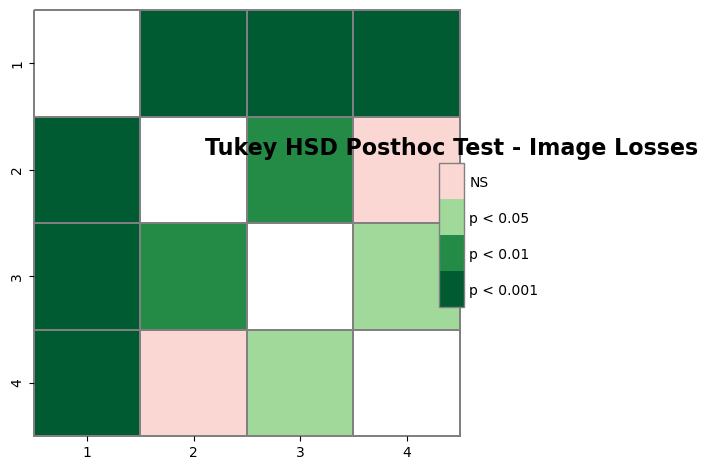

In [19]:
heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}

sp.sign_plot(tukey_results, **heatmap_args)
plt.title('Tukey HSD Posthoc Test - Image Losses', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('./img/turkey_posthoc_image_loss.png', dpi=300)

print(sp.compact_letter_display(tukey_results)) 
print(tukey_results)

## Boxplot

In [20]:
df = pd.DataFrame({
    "loss": (
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_1V] +
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_2V_IS] +
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_2V_IL] +
        [x.item() if hasattr(x, "item") else float(x) for x in im_loss_3V]
    ),
    "model": (
        ["1 Views"] * len(im_loss_1V) +
        ["2 Views - IS"] * len(im_loss_2V_IS) +
        ["2 Views - IL"] * len(im_loss_2V_IL) +
        ["3 Views"] * len(im_loss_3V)
    )
})

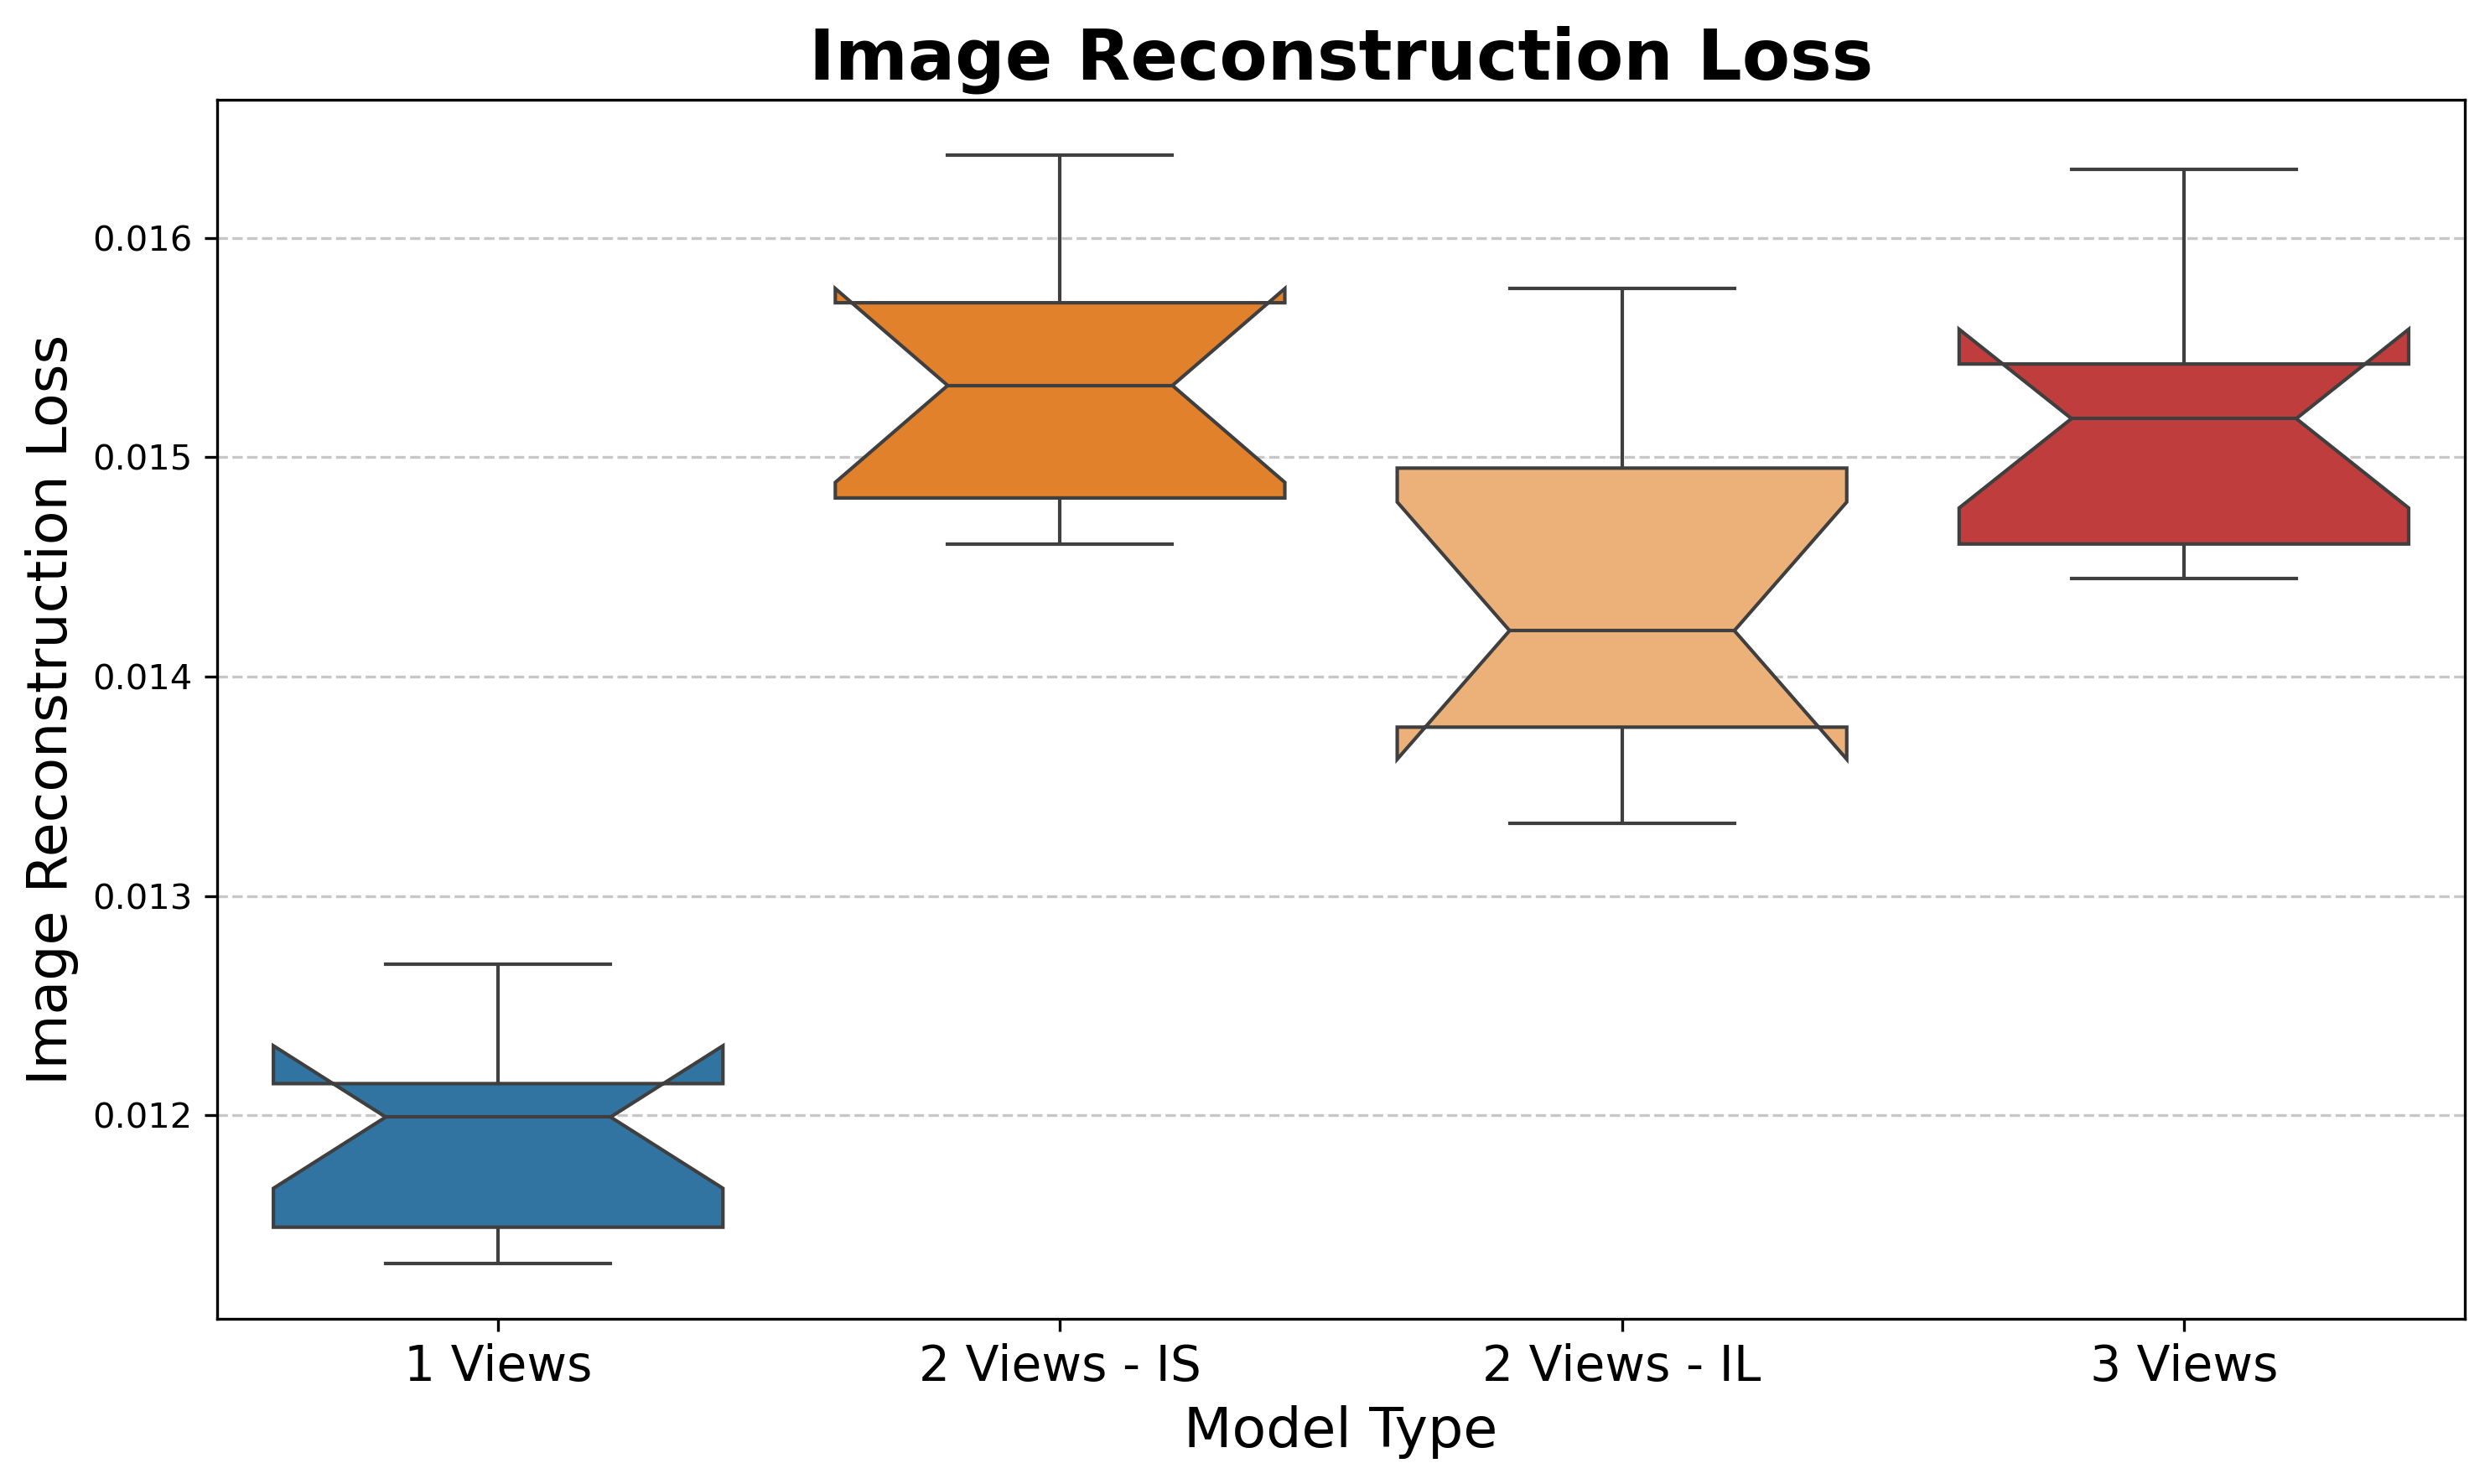

In [21]:
plt.figure(figsize=(10, 6), dpi=300)

sns.boxplot(data=df, x="model", y="loss", notch=True, palette=['tab:blue', 'tab:orange', '#ffb066', 'tab:red'], hue="model")

plt.xlabel("Model Type", fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel("Image Reconstruction Loss", fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Image Reconstruction Loss", fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig('./img/image_reconstruction_loss_boxplot.png', dpi=300)
plt.show()

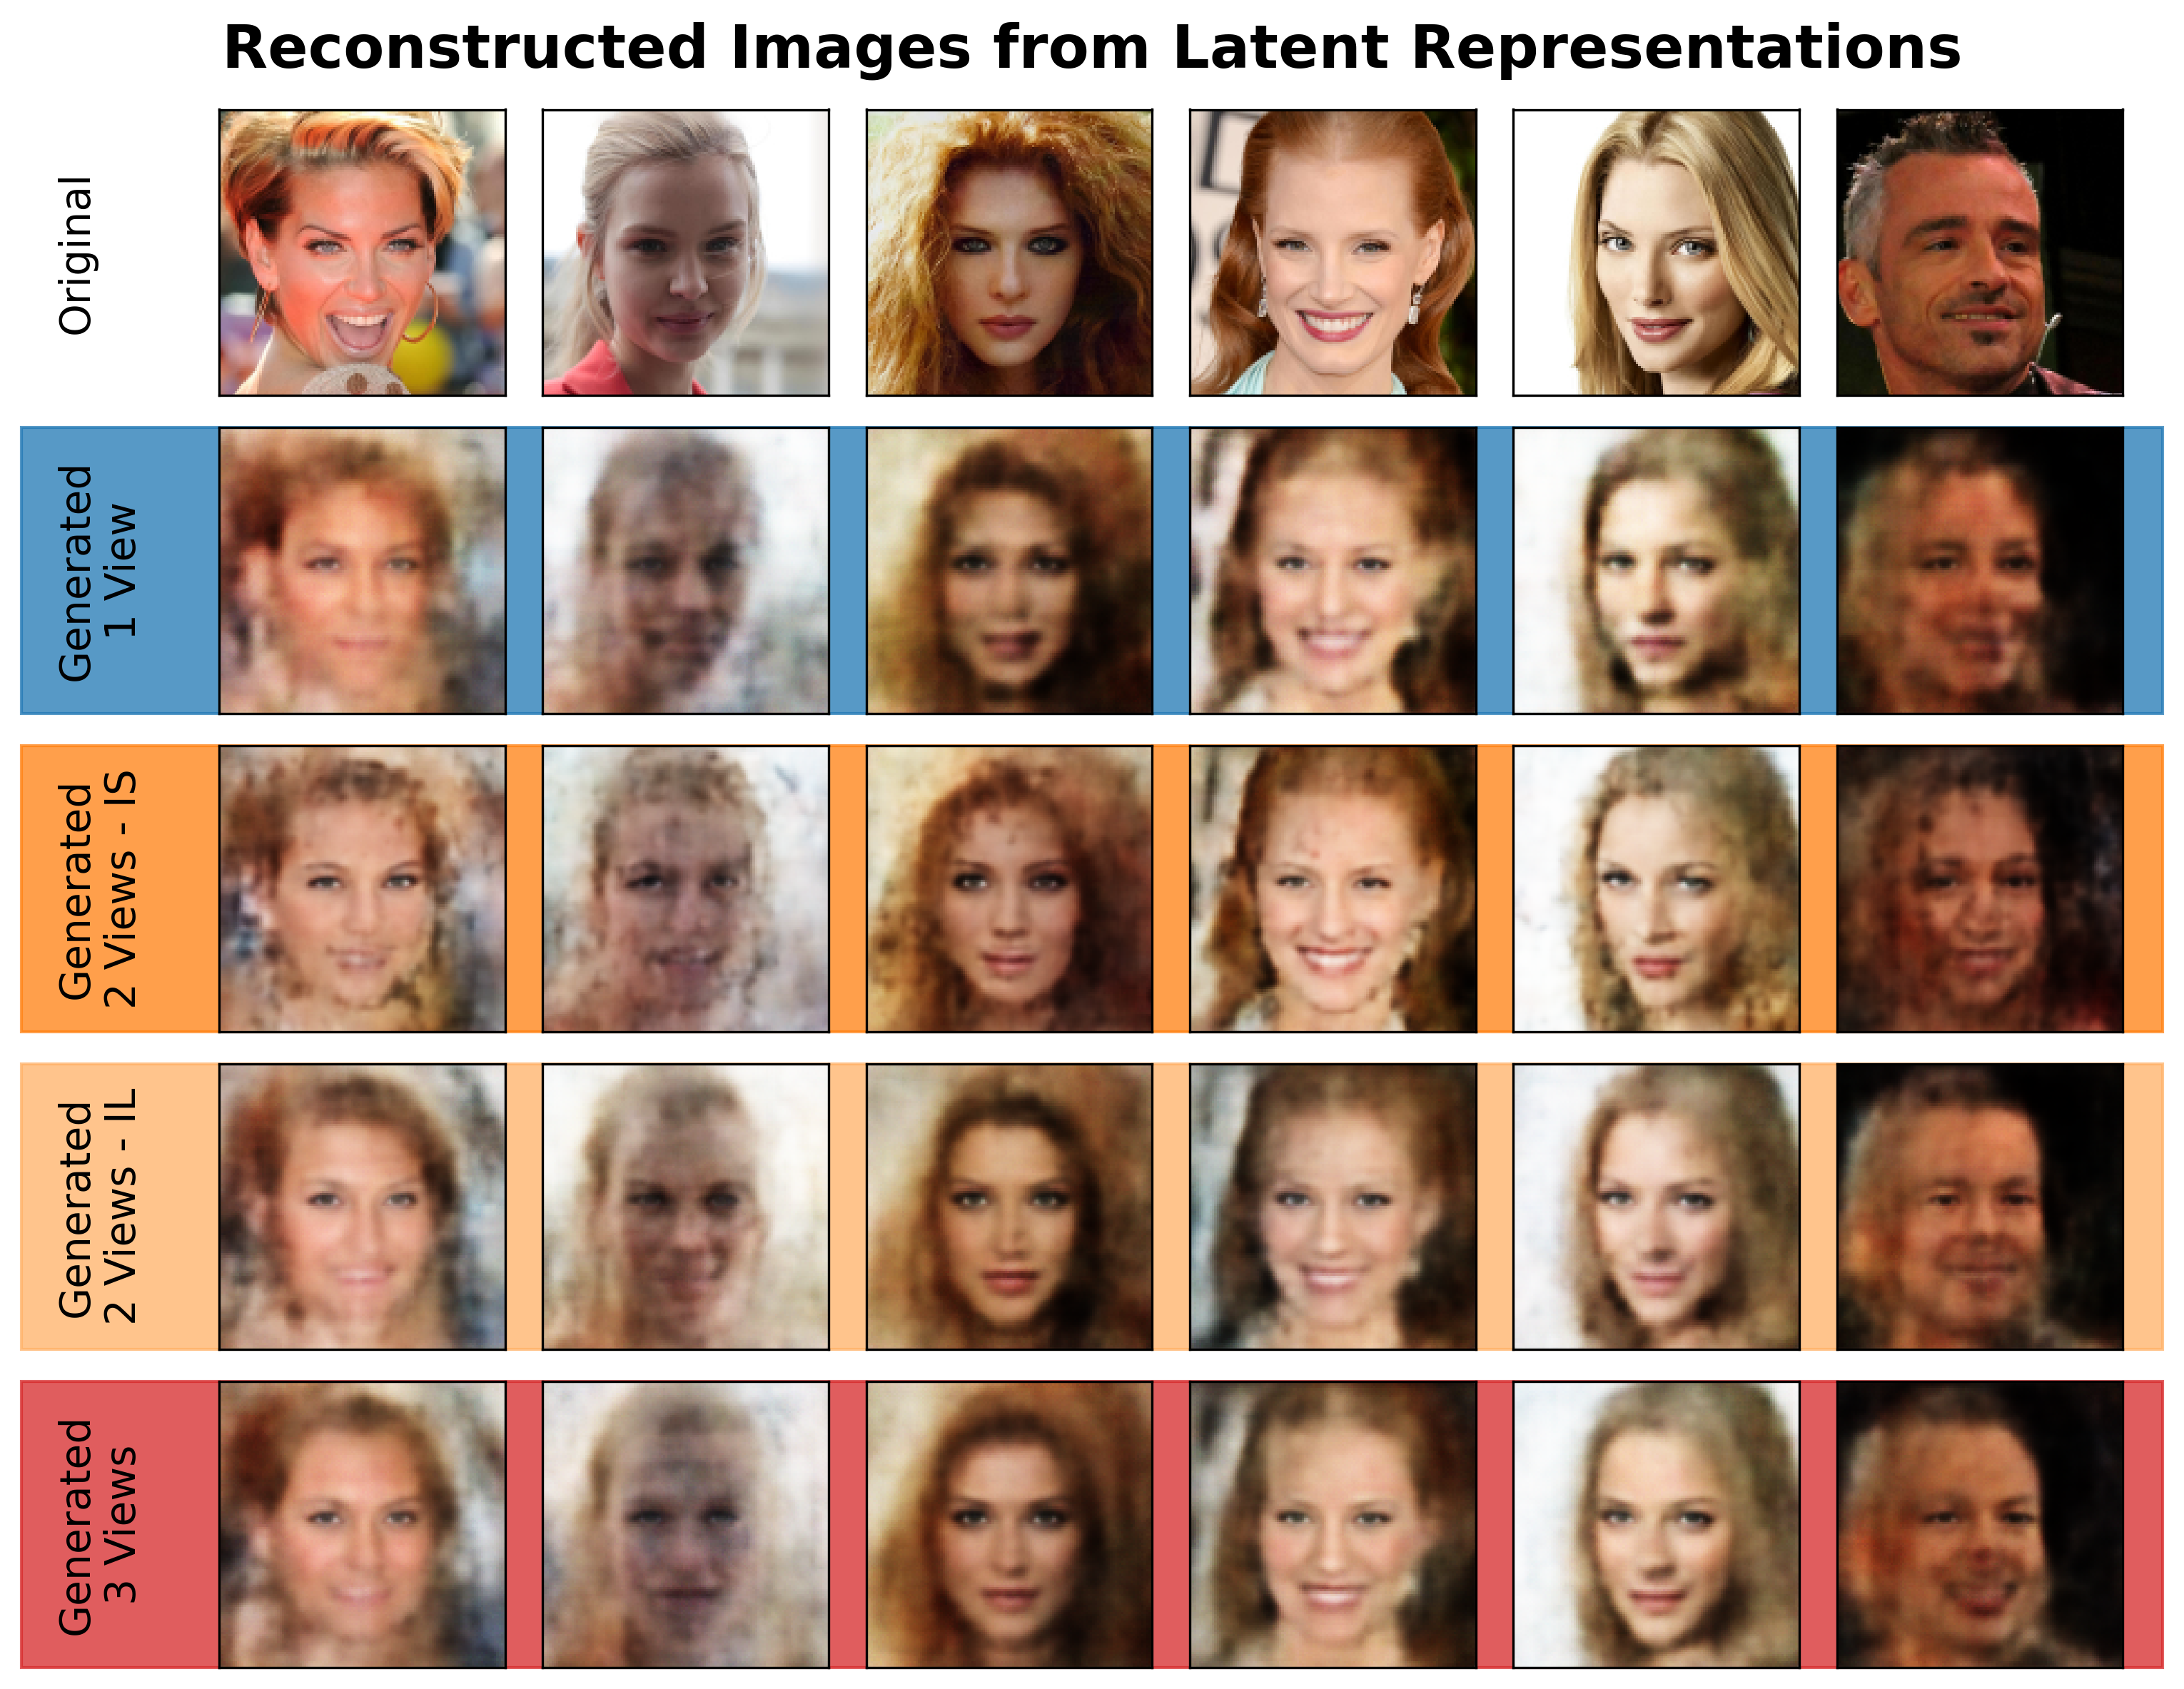

In [22]:
fig, ax = plt.subplots(5, 6, figsize=(10, 8), dpi=300)

for i in range(5):
    for j in range(6):
        if i == 0:
            img = all_data_im[j].permute(1, 2, 0).numpy()
        elif i == 1:
            img = im_de_1V[0][j].permute(1, 2, 0).numpy()
        elif i == 2:
            img = im_de_2V_IS[0][j].permute(1, 2, 0).numpy()
        elif i == 3:
            img = im_de_2V_IL[0][j].permute(1, 2, 0).numpy()
        else:
            img = im_de_3V[0][j].permute(1, 2, 0).numpy()

        ax[i, j].imshow(img)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    if i == 0:
        ax[i, 0].set_ylabel('Original\n', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 1:
        ax[i, 0].set_ylabel('Generated\n1 View', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 2:
        ax[i, 0].set_ylabel('Generated\n2 Views - IS', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 3:
        ax[i, 0].set_ylabel('Generated\n2 Views - IL', fontsize=14, rotation=90, labelpad=40, va='center')
    else:
        ax[i, 0].set_ylabel('Generated\n3 Views', fontsize=14, rotation=90, labelpad=40, va='center')

plt.suptitle('Reconstructed Images from Latent Representations', fontsize=20, fontweight='bold')
plt.tight_layout()
row_colors = [None, 'tab:blue', 'tab:orange', '#ffb066', 'tab:red']

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )



plt.savefig('./img/reconstructed_images_comparison.png', dpi=300)
plt.show()

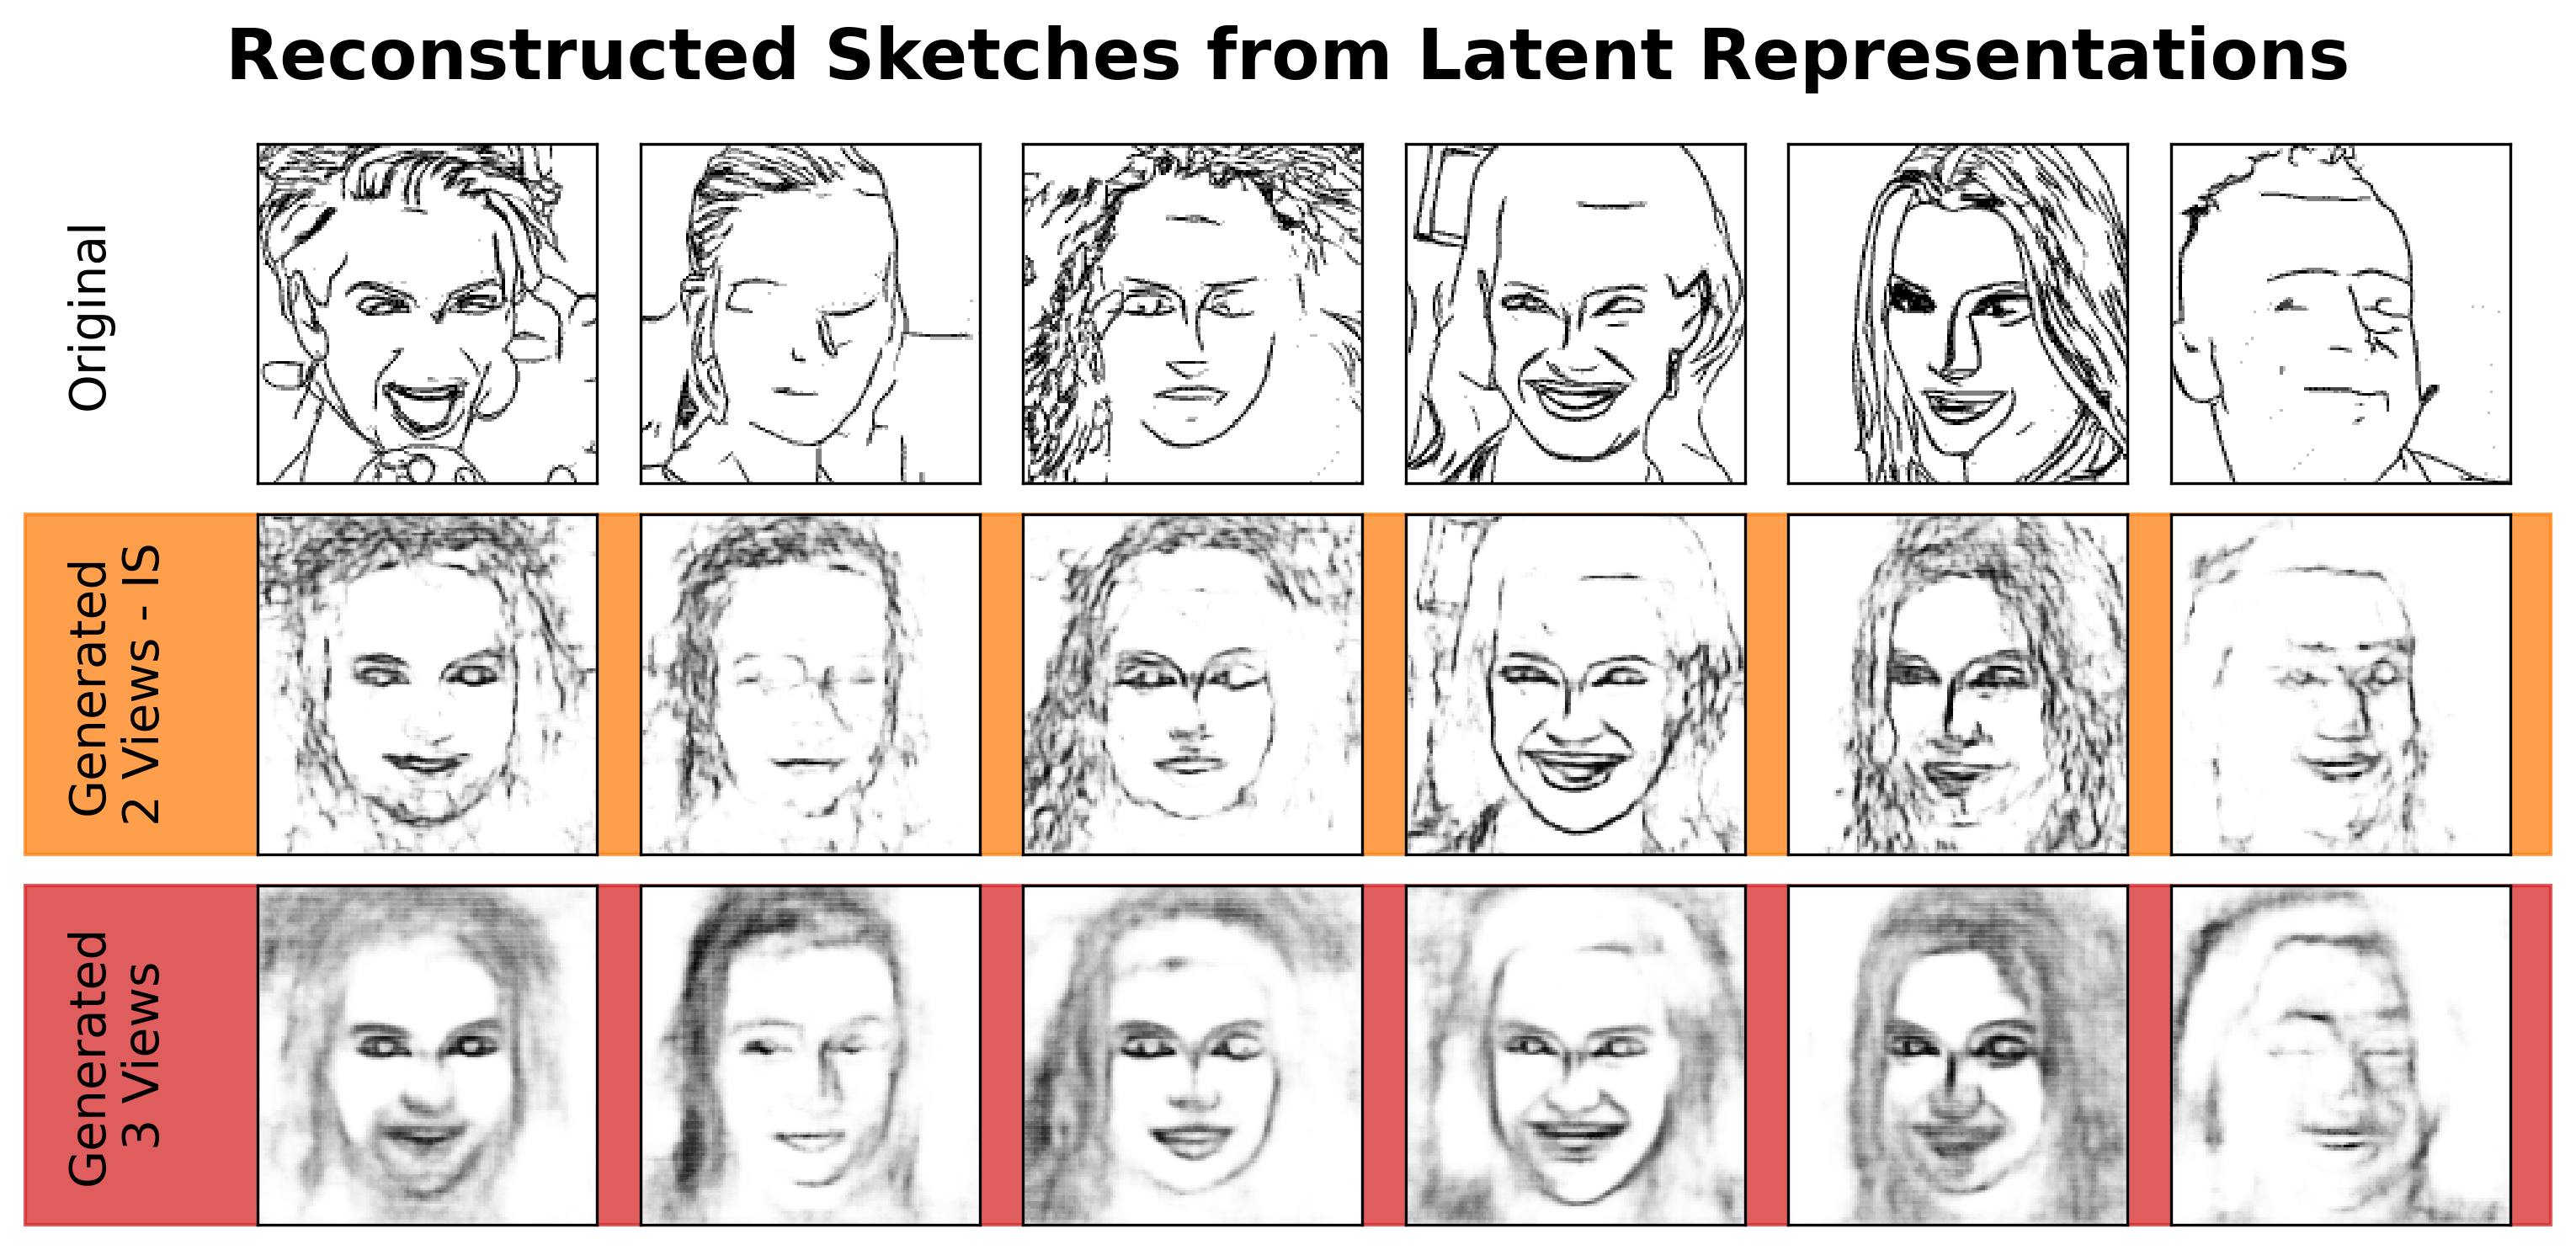

In [23]:
fig, ax = plt.subplots(3, 6, figsize=(10, 5), dpi=300)

for i in range(3):
    for j in range(6):
        if i == 0:
            img = all_data_sk[j].permute(1, 2, 0).numpy()
        elif i == 1:
            img = sk_de_2V_IS[0][j].permute(1, 2, 0).numpy()
        elif i == 2:
            img = sk_de_3V[0][j].permute(1, 2, 0).numpy()

        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    if i == 0:
        ax[i, 0].set_ylabel('Original\n', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 1:
        ax[i, 0].set_ylabel('Generated\n2 Views - IS', fontsize=14, rotation=90, labelpad=40, va='center')
    elif i == 2:
        ax[i, 0].set_ylabel('Generated\n3 Views', fontsize=14, rotation=90, labelpad=40, va='center')

plt.suptitle('Reconstructed Sketches from Latent Representations', fontsize=20, fontweight='bold')
plt.tight_layout()
row_colors = [None, 'tab:orange', 'tab:red']

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )



plt.savefig('./img/reconstructed_sketches_comparison.png', dpi=300)
plt.show()

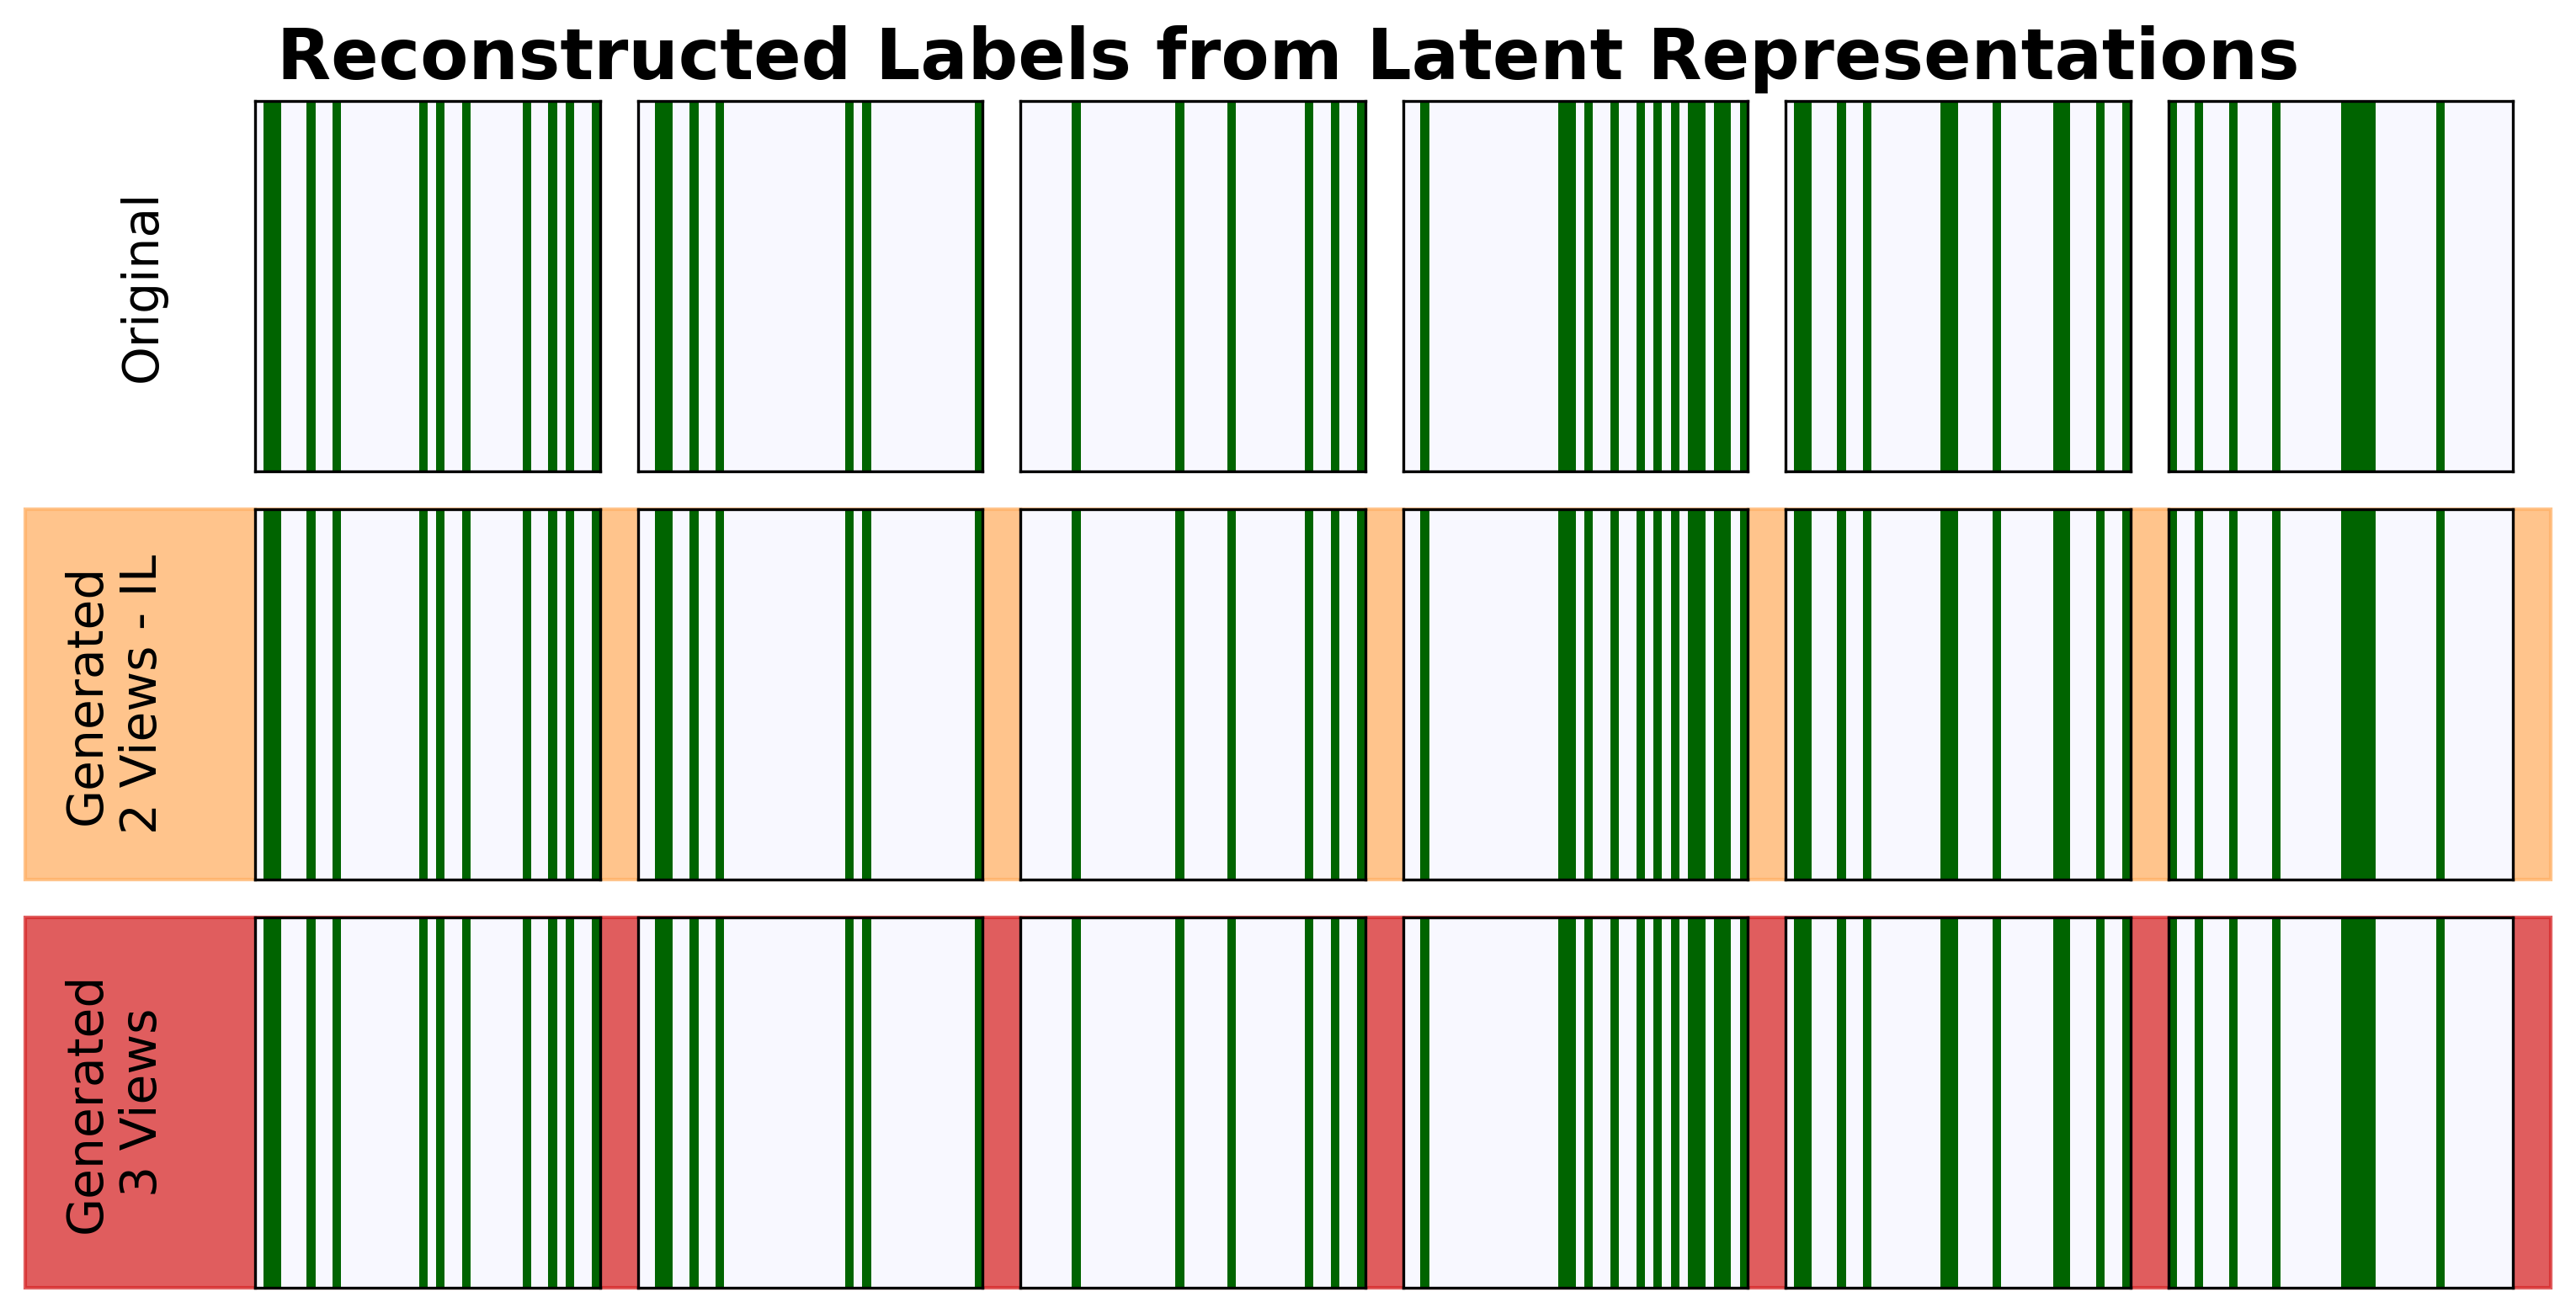

In [24]:
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(3, 6, figsize=(10, 5), dpi=300)

label_sets = [
    all_data_la,
    la_de_2V_IL[0],
    la_de_3V[0]
]

row_colors = [None, '#ffb066', 'tab:red']

row_labels = [
    '\nOriginal',
    'Generated\n2 Views - IL',
    'Generated\n3 Views'
]

cmap = ListedColormap(['ghostwhite', 'darkgreen'])

for i in range(3):
    for j in range(6):
        label_vec = label_sets[i][j].detach().cpu().numpy()

        ax[i, j].imshow(
            label_vec.reshape(1, -1),
            aspect='auto',
            vmin=0,
            vmax=1,
            cmap=cmap
        )

        ax[i, j].set_facecolor('white')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    ax[i, 0].set_ylabel(row_labels[i], fontsize=14, rotation=90, labelpad=40, va='center')

plt.tight_layout()

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = ax[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )

plt.suptitle('Reconstructed Labels from Latent Representations', fontsize=20, fontweight='bold', y=1.03)
plt.savefig('./img/reconstructed_labels_comparison.png', dpi=300, bbox_inches='tight')
plt.show()